# PyTorch 기반 은행 대출 상환/채무불이행 분류 실습

이 노트북은 Google Colab에서 실행 가능한 **PyTorch 코드**로 구현한 것입니다.

의사결정트리를 사용하여 은행 대출 신청자의 채무불이행 여부를 분류합니다.  
같은 분류 문제를 PyTorch의 신경망 분류 모델로 구현합니다.

## 전체 흐름

1. 필요한 라이브러리 설치 및 불러오기  
2. 데이터셋 준비  
3. 데이터 탐색  
4. 범주형/수치형 데이터 전처리  
5. 학습 데이터와 테스트 데이터 분리  
6. PyTorch Dataset / DataLoader 생성  
7. PyTorch 분류 모델 정의  
8. 모델 학습  
9. 테스트 데이터 예측  
10. Confusion Matrix와 정확도 평가


In [558]:
# ============================================================
# 1. 필요한 라이브러리 불러오기
# ============================================================

# pandas는 CSV 파일을 읽고 표 형태의 데이터를 다루기 위한 라이브러리입니다.
import pandas as pd

# numpy는 숫자 배열 계산을 빠르게 처리하기 위한 라이브러리입니다.
import numpy as np

# torch는 PyTorch의 핵심 라이브러리입니다.
# 텐서 생성, 신경망 학습, 자동 미분 등을 처리합니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 만들 때 사용하는 모듈입니다.
import torch.nn as nn

# torch.optim은 Adam, SGD 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# Dataset과 DataLoader는 데이터를 PyTorch 모델에 넣기 좋은 형태로 관리하는 도구입니다.
from torch.utils.data import Dataset, DataLoader

# train_test_split은 데이터를 학습용과 테스트용으로 나누는 함수입니다.
from sklearn.model_selection import train_test_split

# ColumnTransformer는 수치형/범주형 컬럼에 서로 다른 전처리를 적용할 때 사용합니다.
from sklearn.compose import ColumnTransformer

# OneHotEncoder는 문자 범주 데이터를 0과 1의 숫자 벡터로 변환합니다.
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

# Pipeline은 여러 전처리 단계를 하나로 묶어 실행할 때 사용합니다.
from sklearn.pipeline import Pipeline

# accuracy_score와 confusion_matrix는 모델 평가 지표를 계산합니다.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 성능예측용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# 결정트리
from sklearn.tree import DecisionTreeClassifier

# matplotlib은 그래프를 그리기 위한 라이브러리입니다.
import matplotlib.pyplot as plt

# random은 파이썬의 난수 생성을 제어할 때 사용합니다.
import random

# os는 파일 경로 확인 등에 사용합니다.
import os

# 경고 메시지를 줄여 출력 화면을 깔끔하게 만들기 위해 사용합니다.
import warnings

# 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings("ignore")

# 현재 사용 가능한 장치를 확인합니다.
# Colab에서 GPU를 켜면 cuda가 출력되고, 그렇지 않으면 cpu가 출력됩니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 학습에 사용할 장치를 출력합니다.
print("사용 장치:", device)


사용 장치: cuda


In [559]:
# ============================================================
# 2. 난수 고정
# ============================================================

# 난수를 고정하면 코드를 다시 실행해도 최대한 같은 결과가 나오도록 만들 수 있습니다.
SEED = 123

# 파이썬 random 라이브러리의 난수를 고정합니다.
random.seed(SEED)

# numpy 난수를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 연산의 난수를 고정합니다.
torch.manual_seed(SEED)

# PyTorch GPU 연산의 난수를 고정합니다.
torch.cuda.manual_seed_all(SEED)

# CUDA 연산의 재현성을 높이기 위한 설정입니다.
torch.backends.cudnn.deterministic = True

# 실행 속도 최적화보다 재현성을 우선하도록 설정합니다.
torch.backends.cudnn.benchmark = False


## 3. 데이터셋 준비

다음 파일을 사용합니다.

```r
credit_info <- read.csv("data/credit_info.csv", stringsAsFactors = T)
```

Colab에서는 로컬 파일이 없을 수 있으므로 다음 순서로 데이터를 준비합니다.

1. `data/credit_info.csv`가 있으면 그 파일을 사용  
2. 없으면 공개 German Credit 데이터셋 CSV를 자동 다운로드  
3. 목표 컬럼이 `default`로 되어 있으면 `Repay`로 이름을 바꾸어 원본 코드와 비슷하게 맞춤


In [560]:
# ============================================================
# 3. 데이터 불러오기
# ============================================================

# 사용한 파일 경로입니다.
local_path = "data/credit_info.csv"

# 공개 German Credit 데이터셋 주소입니다.
# Colab에서 data/credit_info.csv 파일이 없을 때 자동으로 읽어옵니다.
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/credit.csv"

# data 폴더가 없으면 새로 생성합니다.
os.makedirs("data", exist_ok=True)

# local_path 파일이 실제로 존재하는지 확인합니다.
if os.path.exists(local_path):
    # 파일이 있으면 사용자가 제공한 로컬 CSV 파일을 읽습니다.
    credit_info = pd.read_csv(local_path)
else:
    # 파일이 없으면 공개 URL에서 CSV 파일을 읽습니다.
    credit_info = pd.read_csv(url)

    # 다음 실행 때도 같은 파일을 사용할 수 있도록 data 폴더에 저장합니다.
    credit_info.to_csv(local_path, index=False)

# 목표 변수를 Repay라고 사용합니다.
# 공개 데이터셋은 목표 컬럼명이 default일 수 있으므로 Repay로 바꿉니다.
if "Repay" not in credit_info.columns and "default" in credit_info.columns:
    # default 컬럼명을 Repay로 변경합니다.
    credit_info = credit_info.rename(columns={"default": "Repay"})

# 데이터의 앞부분 5행을 확인합니다.
credit_info.head()


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,Repay,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee


In [561]:
# ============================================================
# 4. 데이터 구조 확인
# ============================================================

# 데이터의 행과 열 개수를 확인합니다.
print("데이터 크기:", credit_info.shape)

# 각 컬럼의 자료형과 결측치 여부를 확인합니다.
credit_info.info()

# 컬럼 이름 목록을 출력합니다.
print("\n컬럼 목록:")
print(credit_info.columns.tolist())


데이터 크기: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_length     1000 non-null   object
 7   installment_rate      1000 non-null   int64 
 8   personal_status       1000 non-null   object
 9   other_debtors         1000 non-null   object
 10  residence_history     1000 non-null   int64 
 11  property              1000 non-null   object
 12  age                   1000 non-null   int64 
 13  installment_plan      1000 non-null   object
 14  housing               1000 non-null   object
 15  existing_credits    

In [562]:
# ============================================================
# 5. 기본 탐색
# ============================================================

# checking_balance 컬럼은 신청자의 수표 계좌 잔고 범주를 의미합니다.
# value_counts()는 R의 table()과 비슷하게 값별 개수를 세어 줍니다.
print("checking_balance 빈도:")
print(credit_info["checking_balance"].value_counts())

# savings_balance 컬럼은 신청자의 저축 계좌 잔고 범주를 의미합니다.
print("\nsavings_balance 빈도:")
print(credit_info["savings_balance"].value_counts())

# months_loan_duration은 대출 기간입니다.
# describe()는 평균, 표준편차, 최솟값, 최댓값 등을 보여줍니다.
print("\nmonths_loan_duration 요약:")
print(credit_info["months_loan_duration"].describe())

# amount는 대출 금액입니다.
print("\namount 요약:")
print(credit_info["amount"].describe())

# Repay는 상환 여부 또는 채무불이행 여부를 나타내는 목표 변수입니다.
print("\nRepay 빈도:")
print(credit_info["Repay"].value_counts())

# Repay 비율을 확인합니다.
print("\nRepay 비율:")
print(credit_info["Repay"].value_counts(normalize=True))


checking_balance 빈도:
checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64

savings_balance 빈도:
savings_balance
< 100 DM         603
unknown          183
101 - 500 DM     103
501 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64

months_loan_duration 요약:
count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: months_loan_duration, dtype: float64

amount 요약:
count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: amount, dtype: float64

Repay 빈도:
Repay
1    700
2    300
Name: count, dtype: int64

Repay 비율:
Repay
1    0.7
2    0.3
Name: proportion, dtype: float64


## 6. 입력 데이터와 정답 데이터 분리

- `X`: 모델이 학습할 입력 특성  
- `y`: 모델이 맞혀야 하는 정답 라벨  

`credit_info_train[-17]`로 마지막 목표 컬럼을 제외했습니다.  
여기서는 컬럼 이름 `Repay`를 기준으로 입력과 정답을 분리합니다.


In [563]:
# ============================================================
# 6. 입력 X와 정답 y 분리
# ============================================================

# 목표 컬럼명을 변수로 저장합니다.
target_col = "Repay"

# 목표 컬럼이 실제 데이터에 있는지 확인합니다.
if target_col not in credit_info.columns:
    # 목표 컬럼이 없으면 에러를 발생시켜 문제 원인을 바로 알 수 있게 합니다.
    raise ValueError("데이터에 Repay 컬럼이 없습니다. 목표 컬럼명을 확인하세요.")

# X는 Repay를 제외한 모든 컬럼입니다.
X = credit_info.drop(columns=[target_col])

# y는 모델이 예측해야 하는 Repay 컬럼입니다.
y = credit_info[target_col]

#------------------------------------------
# LabelEncoder는 문자 라벨을 숫자 라벨로 바꿉니다.
# 예: no -> 0, yes -> 1 과 같은 방식입니다.
label_encoder = LabelEncoder()
## label_encoder = pd.get_dummies(credit_info)


# y 값을 숫자 형태로 변환합니다.
y_encoded = label_encoder.fit_transform(y)

# X(피처)만 원핫 인코딩
# X = pd.get_dummies(X)


#------------------------------------------------
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)
# for original_label, encoded_label in zip(le.classes_, range(len(le.classes_))):
    # print(f"{original_label} -> {encoded_label}")

#-----------------------------------------------------------
# 어떤 원래 라벨이 어떤 숫자로 바뀌었는지 확인합니다.
# print("라벨 매핑:")
for original_label, encoded_label in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{original_label} -> {encoded_label}")


1 -> 0
2 -> 1


In [564]:
# ============================================================
# 7. 수치형 컬럼과 범주형 컬럼 구분
# ============================================================

# 수치형 컬럼은 int64, float64 같은 숫자 자료형 컬럼입니다.
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 범주형 컬럼은 object, category 같은 문자 또는 범주 자료형 컬럼입니다.
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# 수치형 컬럼 목록을 출력합니다.
print("수치형 컬럼:", numeric_features)

# 범주형 컬럼 목록을 출력합니다.
print("범주형 컬럼:", categorical_features)


수치형 컬럼: ['months_loan_duration', 'amount', 'installment_rate', 'residence_history', 'age', 'existing_credits', 'dependents']
범주형 컬럼: ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_length', 'personal_status', 'other_debtors', 'property', 'installment_plan', 'housing', 'telephone', 'foreign_worker', 'job']


In [565]:
# ============================================================
# 8. 학습 데이터와 테스트 데이터 분리
# ============================================================

# train_test_split은 데이터를 학습용과 테스트용으로 나눕니다.
# test_size=0.2는 전체 데이터의 20%를 테스트용으로 사용한다는 뜻입니다.
# 800개 학습 / 200개 테스트 분리와 같은 비율입니다.
# stratify=y_encoded는 정답 라벨 비율이 학습/테스트에 비슷하게 유지되도록 합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

# 분리된 데이터 크기를 확인합니다.
print("X_train 크기:", X_train.shape)
print("X_test 크기:", X_test.shape)
print("y_train 크기:", y_train.shape)
print("y_test 크기:", y_test.shape)

# 학습 데이터의 클래스 비율을 확인합니다.
print("\n학습 데이터 클래스 비율:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

# 테스트 데이터의 클래스 비율을 확인합니다.
print("\n테스트 데이터 클래스 비율:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


X_train 크기: (800, 20)
X_test 크기: (200, 20)
y_train 크기: (800,)
y_test 크기: (200,)

학습 데이터 클래스 비율:
0    0.7
1    0.3
Name: proportion, dtype: float64

테스트 데이터 클래스 비율:
0    0.7
1    0.3
Name: proportion, dtype: float64


## 7. 데이터 전처리

PyTorch 모델은 숫자 텐서만 입력으로 받을 수 있습니다.

따라서 다음 전처리를 수행합니다.

- 수치형 컬럼: 평균 0, 표준편차 1에 가깝도록 표준화  
- 범주형 컬럼: One-Hot Encoding으로 0/1 숫자 벡터 변환


In [566]:
# ============================================================
# 9. 전처리 파이프라인 생성
# ============================================================

# 수치형 데이터 전처리: StandardScaler로 표준화합니다.
numeric_transformer = Pipeline(
    steps=[
        # StandardScaler는 수치 데이터의 크기 차이를 줄여 학습을 안정적으로 만듭니다.
        ("scaler", StandardScaler())
    ]
)

# 범주형 데이터 전처리: OneHotEncoder로 숫자 벡터화합니다.
categorical_transformer = Pipeline(
    steps=[
        # handle_unknown="ignore"는 테스트 데이터에 학습 때 보지 못한 범주가 나와도 에러를 막습니다.
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ColumnTransformer는 컬럼 종류별로 다른 전처리를 적용합니다.
preprocessor = ColumnTransformer(
    transformers=[
        # numeric_features 컬럼에는 numeric_transformer를 적용합니다.
        ("num", numeric_transformer, numeric_features),

        # categorical_features 컬럼에는 categorical_transformer를 적용합니다.
        ("cat", categorical_transformer, categorical_features)
    ]
)

# fit_transform은 학습 데이터 기준으로 전처리 규칙을 학습하고 바로 변환합니다.
X_train_processed = preprocessor.fit_transform(X_train)

# transform은 학습 데이터에서 만든 규칙을 테스트 데이터에 그대로 적용합니다.
X_test_processed = preprocessor.transform(X_test)

# OneHotEncoder 결과가 희소 행렬일 수 있으므로 일반 numpy 배열로 변환합니다.
X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

# PyTorch는 float32 자료형을 주로 사용하므로 float32로 변환합니다.
X_train_processed = X_train_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

# 정답 라벨은 분류 문제에서 long 타입으로 사용합니다.
y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

# 전처리 후 입력 특성 개수를 확인합니다.
print("전처리 후 학습 입력 크기:", X_train_processed.shape)
print("전처리 후 테스트 입력 크기:", X_test_processed.shape)


전처리 후 학습 입력 크기: (800, 61)
전처리 후 테스트 입력 크기: (200, 61)


## 8. PyTorch Dataset과 DataLoader 생성

`Dataset`은 데이터를 한 개씩 꺼내는 방법을 정의합니다.  
`DataLoader`는 데이터를 미니배치 단위로 모델에 공급합니다.


In [567]:
# ============================================================
# 10. PyTorch Dataset 클래스 정의
# ============================================================

# CreditDataset은 대출 데이터를 PyTorch가 사용할 수 있는 형태로 포장하는 클래스입니다.
class CreditDataset(Dataset):
    # __init__은 Dataset 객체가 만들어질 때 한 번 실행됩니다.
    def __init__(self, features, labels):
        # 입력 특성을 torch 텐서로 변환합니다.
        self.features = torch.tensor(features, dtype=torch.float32)

        # 정답 라벨을 torch 텐서로 변환합니다.
        self.labels = torch.tensor(labels, dtype=torch.long)

    # __len__은 데이터가 총 몇 개인지 반환합니다.
    def __len__(self):
        # labels의 길이가 전체 데이터 개수입니다.
        return len(self.labels)

    # __getitem__은 특정 번호의 데이터 1개를 반환합니다.
    def __getitem__(self, idx):
        # idx번째 입력 데이터와 정답 라벨을 함께 반환합니다.
        return self.features[idx], self.labels[idx]


# 학습용 Dataset 객체를 생성합니다.
train_dataset = CreditDataset(X_train_processed, y_train)

# 테스트용 Dataset 객체를 생성합니다.
test_dataset = CreditDataset(X_test_processed, y_test)

# 한 번에 학습할 데이터 개수입니다.
# 32개씩 묶어서 모델에 넣습니다.
batch_size = 32

# 학습용 DataLoader를 생성합니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 학습 효과를 높입니다.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 테스트용 DataLoader를 생성합니다.
# 테스트는 순서를 섞을 필요가 없으므로 shuffle=False입니다.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 첫 번째 미니배치를 꺼내 입력과 정답 크기를 확인합니다.
sample_X, sample_y = next(iter(train_loader))

# 미니배치 입력 크기를 출력합니다.
print("미니배치 입력 크기:", sample_X.shape)

# 미니배치 정답 크기를 출력합니다.
print("미니배치 정답 크기:", sample_y.shape)


미니배치 입력 크기: torch.Size([32, 61])
미니배치 정답 크기: torch.Size([32])


## 9. PyTorch 분류 모델 정의

코드는 C5.0 의사결정트리를 사용했습니다.  
여기서는 PyTorch의 기본 신경망인 MLP, 즉 다층 퍼셉트론을 사용합니다.

구조:

- 입력층: 전처리 후 특성 개수  
- 은닉층 1: 64개 뉴런  
- 은닉층 2: 32개 뉴런  
- 출력층: 클래스 개수  


In [568]:
# ============================================================
# 11. PyTorch 모델 정의
# ============================================================

# CreditMLP는 대출 상환 여부를 분류하는 신경망 모델입니다.
# class CreditMLP(nn.Module):
#     # __init__은 모델 구조를 정의하는 부분입니다.
#     def __init__(self, input_dim, num_classes):
#         # 부모 클래스 nn.Module의 초기화 함수를 실행합니다.
#         super(CreditMLP, self).__init__()

#         # self.network는 여러 신경망 계층을 순서대로 묶은 구조입니다.
#         self.network = nn.Sequential(
#             # 첫 번째 완전연결층입니다.
#             # input_dim개의 입력을 받아 64개의 값으로 변환합니다.
#             nn.Linear(input_dim, 64),

#             # ReLU는 음수는 0으로, 양수는 그대로 통과시키는 활성화 함수입니다.
#             # 모델이 복잡한 패턴을 학습할 수 있게 도와줍니다.
#             nn.ReLU(),

#             # Dropout은 일부 뉴런을 무작위로 끄는 기법입니다.
#             # 과적합을 줄이는 데 도움이 됩니다.
#             nn.Dropout(0.2),

#             # 두 번째 완전연결층입니다.
#             # 64개의 입력을 받아 32개의 값으로 변환합니다.
#             nn.Linear(64, 32),

#             # 두 번째 ReLU 활성화 함수입니다.
#             nn.ReLU(),

#             # 마지막 출력층입니다.
#             # 32개의 입력을 클래스 개수만큼의 점수로 변환합니다.
#             nn.Linear(32, num_classes)
#         )

#     # forward는 입력 데이터가 모델을 통과하는 계산 과정을 정의합니다.
#     def forward(self, x):
#         # 입력 x를 self.network에 통과시켜 출력값을 만듭니다.
#         return self.network(x)


# 입력 특성 개수입니다.
input_dim = X_train_processed.shape[1]

# 분류할 클래스 개수입니다.
num_classes = len(label_encoder.classes_)

# 모델 객체를 생성하고 학습 장치(cpu 또는 cuda)로 이동합니다.
# model = CreditMLP(input_dim=input_dim, num_classes=num_classes).to(device)



model = DecisionTreeClassifier(
    # max_depth=None, # 3, 5, 7, 10, None
    # min_samples_split=2, #2 5 10 20 50
    min_samples_leaf=1,
    random_state=42
)

# 모델 구조를 출력합니다.
print(model)


DecisionTreeClassifier(random_state=42)


In [569]:
# ============================================================
# 12. 손실 함수와 최적화 알고리즘 설정
# ============================================================

# CrossEntropyLoss는 다중 분류 문제에서 많이 사용하는 손실 함수입니다.
# 모델의 예측이 정답과 얼마나 다른지 숫자로 계산합니다.
# criterion = nn.CrossEntropyLoss()

# Adam은 학습률을 자동으로 조정해 가며 모델 파라미터를 업데이트하는 최적화 알고리즘입니다.
# optimizer = optim.Adam(
#     model.parameters(),  # 학습할 모델 파라미터를 지정합니다.
#     lr=0.001             # learning rate, 즉 한 번에 얼마나 크게 수정할지 정합니다.
# )



## 10. 모델 학습

아래 코드는 epoch마다 다음 값을 출력합니다.

- 학습 손실값  
- 학습 정확도  
- 테스트 손실값  
- 테스트 정확도  

손실값은 낮을수록 좋고, 정확도는 높을수록 좋습니다.


In [570]:
# ============================================================
# 13. 평가 함수 정의
# ============================================================

# evaluate 함수는 검증 또는 테스트 데이터에서 모델 성능을 계산합니다.
def evaluate(model, data_loader, criterion):
    # 모델을 평가 모드로 바꿉니다.
    # Dropout 같은 학습 전용 동작이 꺼집니다.
    model.eval()

    # 전체 손실값을 누적할 변수입니다.
    total_loss = 0.0

    # 맞힌 개수를 누적할 변수입니다.
    correct = 0

    # 전체 데이터 개수를 누적할 변수입니다.
    total = 0

    # 평가할 때는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
    with torch.no_grad():
        # DataLoader에서 미니배치 단위로 데이터를 꺼냅니다.
        for batch_X, batch_y in data_loader:
            # 입력 데이터를 학습 장치로 이동합니다.
            batch_X = batch_X.to(device)

            # 정답 라벨을 학습 장치로 이동합니다.
            batch_y = batch_y.to(device)

            # 모델에 입력 데이터를 넣어 예측 점수를 계산합니다.
            outputs = model(batch_X)

            # 예측 점수와 정답 사이의 손실값을 계산합니다.
            loss = criterion(outputs, batch_y)

            # 현재 미니배치 손실값에 데이터 개수를 곱해 누적합니다.
            total_loss += loss.item() * batch_X.size(0)

            # 가장 점수가 높은 클래스 번호를 예측값으로 선택합니다.
            _, predicted = torch.max(outputs, 1)

            # 전체 데이터 개수를 누적합니다.
            total += batch_y.size(0)

            # 예측값과 정답이 같은 개수를 누적합니다.
            correct += (predicted == batch_y).sum().item()

    # 평균 손실값을 계산합니다.
    avg_loss = total_loss / total

    # 정확도를 계산합니다.
    accuracy = correct / total

    # 평균 손실값과 정확도를 반환합니다.
    return avg_loss, accuracy


In [571]:
# # ============================================================
# # 14. 모델 학습 실행
# # ============================================================

model.fit(X_train_processed, y_train)


# # 전체 학습 반복 횟수입니다.
# epochs = 50

# # 학습 과정을 저장할 리스트입니다.
# train_losses = []
# train_accuracies = []
# test_losses = []
# test_accuracies = []

# # epoch 수만큼 반복 학습합니다.
# for epoch in range(epochs):
#     # 모델을 학습 모드로 바꿉니다.
#     # Dropout 같은 학습 전용 동작이 켜집니다.
#     model.train()

#     # 한 epoch 동안의 손실값을 누적할 변수입니다.
#     running_loss = 0.0

#     # 한 epoch 동안 맞힌 개수를 누적할 변수입니다.
#     correct = 0

#     # 한 epoch 동안 전체 데이터 개수를 누적할 변수입니다.
#     total = 0

#     # 학습 데이터를 미니배치 단위로 반복합니다.
#     for batch_X, batch_y in train_loader:
#         # 입력 데이터를 학습 장치로 이동합니다.
#         batch_X = batch_X.to(device)

#         # 정답 라벨을 학습 장치로 이동합니다.
#         batch_y = batch_y.to(device)

#         # 이전 미니배치에서 계산된 기울기를 초기화합니다.
#         optimizer.zero_grad()

#         # 모델에 입력 데이터를 넣어 예측 점수를 계산합니다.
#         outputs = model(batch_X)

#         # 예측 결과와 실제 정답 사이의 손실값을 계산합니다.
#         loss = criterion(outputs, batch_y)

#         # 손실값을 기준으로 각 파라미터의 기울기를 계산합니다.
#         loss.backward()

#         # 계산된 기울기를 사용하여 모델 파라미터를 업데이트합니다.
#         optimizer.step()

#         # 현재 미니배치 손실값을 누적합니다.
#         running_loss += loss.item() * batch_X.size(0)

#         # 가장 큰 점수를 가진 클래스를 예측값으로 선택합니다.
#         _, predicted = torch.max(outputs, 1)

#         # 전체 데이터 개수를 누적합니다.
#         total += batch_y.size(0)

#         # 예측값과 정답이 같은 개수를 누적합니다.
#         correct += (predicted == batch_y).sum().item()

#     # 한 epoch의 평균 학습 손실값을 계산합니다.
#     train_loss = running_loss / total

#     # 한 epoch의 학습 정확도를 계산합니다.
#     train_acc = correct / total

#     # 테스트 데이터에 대한 손실값과 정확도를 계산합니다.
#     test_loss, test_acc = evaluate(model, test_loader, criterion)

#     # 그래프 출력을 위해 값을 리스트에 저장합니다.
#     train_losses.append(train_loss)
#     train_accuracies.append(train_acc)
#     test_losses.append(test_loss)
#     test_accuracies.append(test_acc)

#     # epoch마다 학습 결과를 출력합니다.
#     print(
#         f"Epoch [{epoch + 1:02d}/{epochs}] "
#         f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
#         f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
#     )


DecisionTreeClassifier(random_state=42)

In [572]:
# # ============================================================
# # 15. 학습 과정 그래프 출력
# # ============================================================

# # 그래프 크기를 지정합니다.
# plt.figure(figsize=(8, 5))

# # 학습 손실값 변화를 선 그래프로 표시합니다.
# plt.plot(train_losses, label="Train Loss")

# # 테스트 손실값 변화를 선 그래프로 표시합니다.
# plt.plot(test_losses, label="Test Loss")

# # 그래프 제목을 지정합니다.
# plt.title("Loss 변화")

# # x축 이름을 지정합니다.
# plt.xlabel("Epoch")

# # y축 이름을 지정합니다.
# plt.ylabel("Loss")

# # 범례를 표시합니다.
# plt.legend()

# # 그래프를 출력합니다.
# plt.show()

# # 새로운 그래프 크기를 지정합니다.
# plt.figure(figsize=(8, 5))

# # 학습 정확도 변화를 선 그래프로 표시합니다.
# plt.plot(train_accuracies, label="Train Accuracy")

# # 테스트 정확도 변화를 선 그래프로 표시합니다.
# plt.plot(test_accuracies, label="Test Accuracy")

# # 그래프 제목을 지정합니다.
# plt.title("Accuracy 변화")

# # x축 이름을 지정합니다.
# plt.xlabel("Epoch")

# # y축 이름을 지정합니다.
# plt.ylabel("Accuracy")

# # 범례를 표시합니다.
# plt.legend()

# # 그래프를 출력합니다.
# plt.show()


## 11. 테스트 데이터 예측 및 성능 평가

Python에서는 `confusion_matrix()`로 수행합니다.


In [573]:
# # ============================================================
# # 16. 테스트 데이터 전체 예측
# # ============================================================


# # 모델을 평가 모드로 변경합니다.
# model.eval()

# # 예측값을 저장할 리스트입니다.
all_predictions = []

# # 실제 정답을 저장할 리스트입니다.
all_labels = []
all_labels = y_test

# # 테스트 과정에서는 기울기 계산이 필요 없으므로 no_grad를 사용합니다

all_predictions = model.predict(X_test_processed)

# with torch.no_grad():
#     # 테스트 데이터를 미니배치 단위로 반복합니다.
#     for batch_X, batch_y in test_loader:
#         # 입력 데이터를 학습 장치로 이동합니다.
#         batch_X = batch_X.to(device)

#         # 모델 예측 점수를 계산합니다.
#         outputs = model(batch_X)

#         # 가장 점수가 높은 클래스를 예측값으로 선택합니다.
#         _, predicted = torch.max(outputs, 1)

#         # 예측값을 CPU로 옮긴 뒤 numpy 배열로 변환하여 리스트에 추가합니다.
#         all_predictions.extend(predicted.cpu().numpy())

#         # 실제 정답도 numpy 배열로 변환하여 리스트에 추가합니다.
#         all_labels.extend(batch_y.numpy())

# # 리스트를 numpy 배열로 변환합니다.
all_predictions = np.array(all_predictions)
# all_labels = np.array(all_labels)

# # 정확도를 계산합니다.
test_accuracy = accuracy_score(all_labels, all_predictions)

# # 테스트 정확도를 출력합니다.
print("테스트 정확도:", round(test_accuracy, 4))


테스트 정확도: 0.68


In [574]:
# ============================================================
# 17. Confusion Matrix 출력
# ============================================================

# Confusion Matrix를 계산합니다.
cm = confusion_matrix(all_labels, all_predictions)

# Confusion Matrix를 표 형태의 DataFrame으로 변환합니다.
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{label}" for label in label_encoder.classes_],
    columns=[f"Pred_{label}" for label in label_encoder.classes_]
)

# Confusion Matrix를 출력합니다.
cm_df


,Pred_1,Pred_2
Actual_1,106,34
Actual_2,30,30


In [575]:
# ============================================================
# 18. 상세 분류 리포트 출력
# ============================================================

# classification_report는 precision, recall, f1-score를 한 번에 보여줍니다.
# precision은 예측한 것 중 실제로 맞은 비율입니다.
# recall은 실제 정답 중 모델이 찾아낸 비율입니다.
# f1-score는 precision과 recall을 함께 고려한 점수입니다.
report = classification_report(
    all_labels,
    all_predictions,
    target_names=[str(cls) for cls in label_encoder.classes_]
)

# 상세 평가 결과를 출력합니다.
print(report)


              precision    recall  f1-score   support

           1       0.78      0.76      0.77       140
           2       0.47      0.50      0.48        60

    accuracy                           0.68       200
   macro avg       0.62      0.63      0.63       200
weighted avg       0.69      0.68      0.68       200



In [576]:
# ============================================================
# 19. 신규 대출 신청자 예측 예시
# ============================================================

# 1. 테스트 데이터에서 첫 번째 신청자 데이터를 하나 가져옵니다.
new_applicant = X_test.iloc[[0]]
# 신규 신청자 데이터를 확인합니다.
display(new_applicant)

# 2. 학습 데이터 기준으로 만든 전처리기를 사용하여 신규 데이터를 변환합니다.
new_applicant_processed = preprocessor.transform(new_applicant)

# 희소 행렬이면 일반 배열로 변환합니다.
new_applicant_processed = (
    new_applicant_processed.toarray()
    if hasattr(new_applicant_processed, "toarray")
    else new_applicant_processed
)

# 3. 모델 예측 (결정 트리는 바로 numpy/배열을 받습니다)
# 클래스 번호(0 또는 1) 예측
predicted_class = model.predict(new_applicant_processed)[0]

# 각 클래스별 확률 예측 (PyTorch의 softmax 역할)
probabilities = model.predict_proba(new_applicant_processed)[0]

# 4. 숫자 라벨을 원래 문자 라벨로 되돌립니다.
predicted_label = label_encoder.inverse_transform([predicted_class])[0]

# 5. 결과 출력
print("예측 라벨:", predicted_label)

# 6. 클래스별 예측 확률 출력
for label, prob in zip(label_encoder.classes_, probabilities):
    print(f"{label} 확률: {prob:.4f}")

# model.predict()



,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,residence_history,property,age,installment_plan,housing,existing_credits,dependents,telephone,foreign_worker,job
285,< 0 DM,47,repaid,car (new),10722,< 100 DM,0 - 1 yrs,1,female,none,1,real estate,35,none,own,1,1,yes,yes,unskilled resident


예측 라벨: 2
1 확률: 0.0000
2 확률: 1.0000


#[ 실습 프로젝트 : 의사결정트리 정확도 향상 ]

## 실습 목표
현재 생성된 Decision Tree 모델의 성능을 분석하고 다양한 방법으로 정확도를 향상시켜 본다.

# 과제 1
# 문제 1. 현재 모델 성능 분석 ===============================
현재 생성된 모델의 다음 성능지표를 출력하시오.

* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix


In [577]:
acc = accuracy_score(y_test, all_predictions)

prec = precision_score(
    y_test,
    all_predictions,
    average='weighted'
)

rec = recall_score(
    y_test,
    all_predictions,
    average='weighted'
)

f1 = f1_score(
    y_test,
    all_predictions,
    average='weighted'
)

print("Accuracy :", acc)
print("Precision :", prec)
print("Recall :", rec)
print("F1 :", f1)

print(confusion_matrix(y_test,all_predictions))

Accuracy : 0.68
Precision : 0.6862132352941177
Recall : 0.68
F1 : 0.6828424497428704
[[106  34]
 [ 30  30]]


# 결과 n 개 한번에 확인

In [578]:
# 실험할 n값들
n_list_mxdpth = [3, 5, 7, 10]#, None]
n_list_split = [2, 5, 10, 20, 50]
n_list_leaf = [1, 5, 10, 20, 30]
n_list_crit = ['gini', 'entropy']
all_results = []

for n in n_list_mxdpth:
# for n in n_list_split:
# for n in n_list_leaf:
# for n in n_list_crit:
    # --- 모델 학습 및 예측 부분 (기존 코드) ---
    model = DecisionTreeClassifier(
        # criterion=n,
        max_depth=n,
        # min_samples_leaf=n,
        # min_samples_split=n,
        random_state=42)
    model.fit(X_train_processed, y_train)
    pred = model.predict(X_test_processed)

    # --- 지표 계산 ---
    acc = accuracy_score(all_labels, pred)
    pre = precision_score(all_labels, pred, average='weighted')
    rec = recall_score(all_labels, pred, average='weighted')
    f1 = f1_score(all_labels, pred, average='weighted')

    # 리스트에 저장
    all_results.append([n, acc, pre, rec, f1])

# --- 결과 표 출력 ---
print(f"{'n':>3} | {'Acc':>6} | {'Pre':>6} | {'Rec':>6} | {'F1':>6}")
print("-" * 40)
for res in all_results:
    print(f"{res[0]:>3} | {res[1]:.4f} | {res[2]:.4f} | {res[3]:.4f} | {res[4]:.4f}")

  n |    Acc |    Pre |    Rec |     F1
----------------------------------------
  3 | 0.7150 | 0.6876 | 0.7150 | 0.6862
  5 | 0.7000 | 0.6647 | 0.7000 | 0.6645
  7 | 0.7000 | 0.6795 | 0.7000 | 0.6850
 10 | 0.6900 | 0.6842 | 0.6900 | 0.6868


# 영향력 확인

In [579]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train_processed, y_train)

# original_features = credit_info.drop(X_train.columns, axis=1).columns
importance = model.feature_importances_

for feature, score in zip(
    # original_features,
    X_train.columns,
    importance
):
    print(feature, score)

checking_balance 0.10783889600732918
months_loan_duration 0.135519067335502
credit_history 0.0
purpose 0.04377695536449099
amount 0.07621390175798469
savings_balance 0.0
employment_length 0.0
installment_rate 0.0
personal_status 0.022679968832328073
other_debtors 0.0
residence_history 0.3346760317961536
property 0.0
age 0.0
installment_plan 0.0
housing 0.05302642119776252
existing_credits 0.0
dependents 0.01675098415229006
telephone 0.00942631881247466
foreign_worker 0.022355038748162085
job 0.0


# 트리구조 시각화

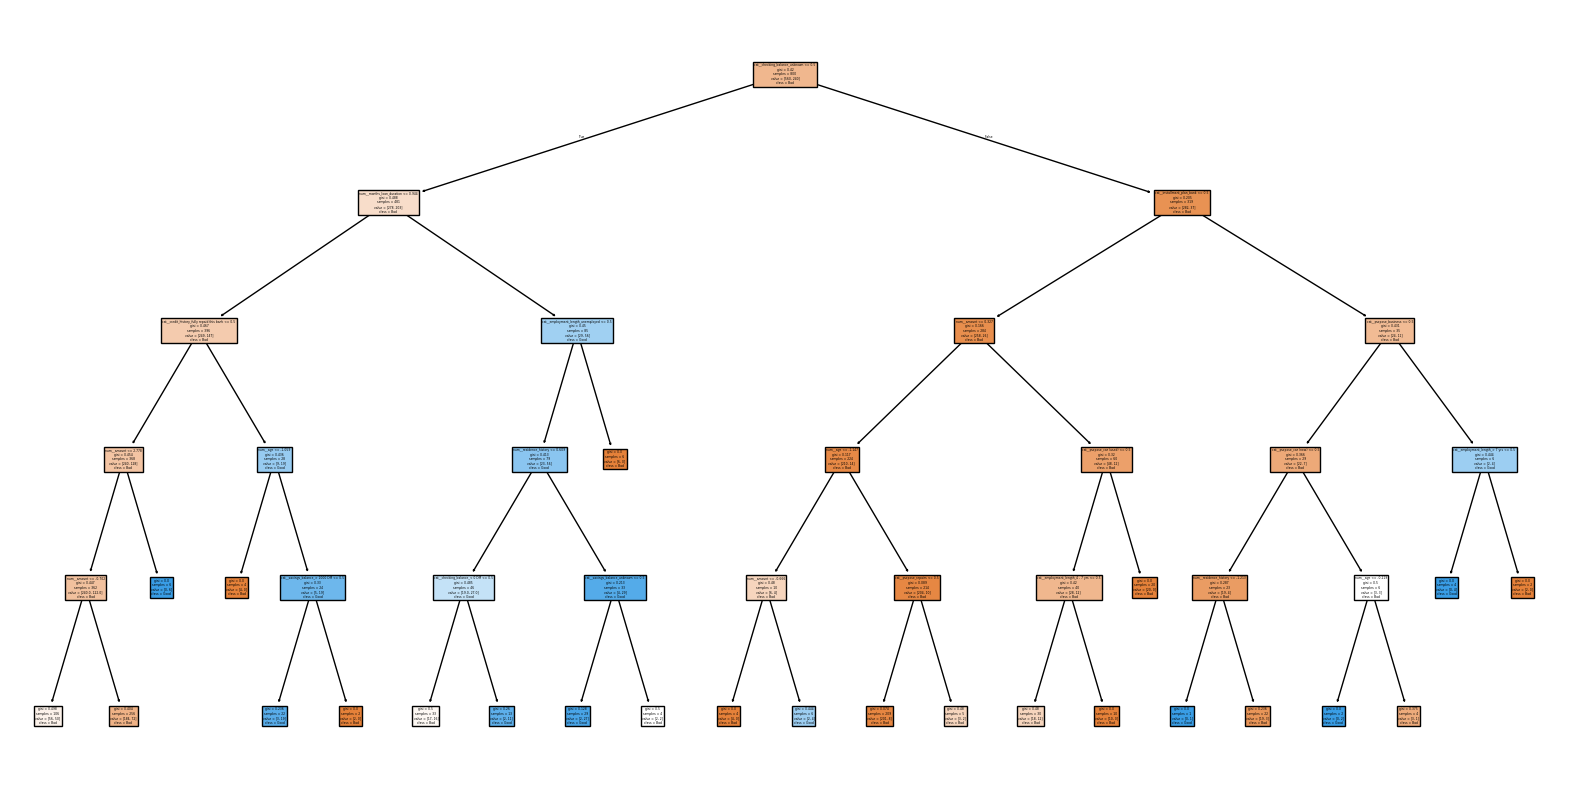

진짜 루트 노드 변수: cat__checking_balance_unknown


In [580]:
from sklearn.tree import plot_tree

# 1. preprocessor에서 전처리된 최종 컬럼명(이름표) 추출
feature_names_out = preprocessor.get_feature_names_out()

plt.figure(figsize=(20,10))

plot_tree(
    model,
    # feature_names=feature_names,
    # class_names=class_names,
    # feature_names=X_train_processed,  # 특성 이름 (연봉, 나이 등)
    feature_names=feature_names_out,
    class_names=['Bad', 'Good'],    # 클래스 이름 (0과 1의 실제 의미)
    filled=True
)

plt.show()

import numpy as np
best_feature_idx = np.argmax(model.feature_importances_)
print("진짜 루트 노드 변수:", feature_names_out[best_feature_idx])

# 8


# 렌덤포레스트로 마지막 문제 확인

In [581]:
from sklearn.ensemble import RandomForestClassifier

# 1. 모델 생성
# n_estimators: 심을 나무의 개수 (보통 100개를 기본으로 합니다)
# max_depth: 각 나무의 최대 깊이 (아까 3~5가 좋았으니 비슷하게 시작해봅니다)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1  # 모든 CPU 코어를 사용하여 빠르게 학습
)

# 2. 모델 학습 (전처리된 데이터를 그대로 넣으세요)
rf_model.fit(X_train_processed, y_train)

# 3. 예측 및 정확도 확인
from sklearn.metrics import accuracy_score, classification_report

rf_pred = rf_model.predict(X_test_processed)
print(f"랜덤 포레스트 정확도: {accuracy_score(y_test, rf_pred):.4f}")

랜덤 포레스트 정확도: 0.7350


In [582]:
import pandas as pd

# 중요도 추출
rf_importance = rf_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

# 보기 좋게 데이터프레임으로 만들기
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importance
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10)) # 상위 10개 확인

                          feature  importance
1                     num__amount    0.099225
0       num__months_loan_duration    0.080072
4                        num__age    0.073448
10  cat__checking_balance_unknown    0.050970
8    cat__checking_balance_< 0 DM    0.046343
3          num__residence_history    0.033930
2           num__installment_rate    0.031797
28  cat__savings_balance_< 100 DM    0.022016
11   cat__credit_history_critical    0.020771
5           num__existing_credits    0.018064


In [583]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. 모델 생성 (max_iter는 계산을 충분히 반복하라는 뜻입니다)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. 모델 학습 (원핫인코딩이 완료된 X_train_processed를 넣으세요)
lr_model.fit(X_train_processed, y_train)

# 3. 예측 및 정확도 확인
lr_pred = lr_model.predict(X_test_processed)
print(f"로지스틱 회귀 정확도: {accuracy_score(y_test, lr_pred):.4f}")

로지스틱 회귀 정확도: 0.7250


# 원본에 가까운 데이터를 넣어서 오차 수치 늘리기



In [584]:
# 이건 '실패'를 확인하기 위한 대조 실험
from sklearn.linear_model import LogisticRegression

# 1. 전처리가 안 된 원본 X_train을 그대로
# (글자가 섞여 있으면 에러가 날 테니, 숫자만 있는 컬럼만 골라서 넣어보세요)
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

lr_simple = LogisticRegression(max_iter=1000)
lr_simple.fit(X_train_numeric, y_train)

print(f"인코딩/전처리 없는 생 데이터 정확도: {lr_simple.score(X_test_numeric, y_test):.4f}")

인코딩/전처리 없는 생 데이터 정확도: 0.7200


# 다른 모델들 확인

In [585]:
# ============================================================
# 인코딩(원핫 vs 라벨/순서) × 모델(트리/랜덤포레스트/로지스틱) 비교
# ============================================================
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
import pandas as pd

# --- 전처리기 2종: 범주형 인코더만 다르고 나머지는 동일 ---
def make_preprocessor(cat_encoder):
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", cat_encoder, categorical_features),
    ])

pre_onehot = make_preprocessor(
    OneHotEncoder(handle_unknown="ignore")
)
pre_ordinal = make_preprocessor(
    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
)

encoders = {"원핫": pre_onehot, "라벨(순서)": pre_ordinal}

models = {
    "결정트리":      DecisionTreeClassifier(max_depth=1, random_state=42),
    "랜덤포레스트":  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "로지스틱회귀":  LogisticRegression(max_iter=1000),
}

rows = []
preds_store = {}   # 뒤 셀에서 예측 직접 비교용

for enc_name, pre in encoders.items():
    Xtr = pre.fit_transform(X_train)
    Xte = pre.transform(X_test)
    # 희소행렬이면 일반 배열로
    Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte

    for model_name, model in models.items():
        m = model.__class__(**model.get_params())   # 매번 새 모델
        m.fit(Xtr, y_train)
        pred  = m.predict(Xte)
        proba = m.predict_proba(Xte)

        rows.append({
            "모델": model_name,
            "인코딩": enc_name,
            "Accuracy":  accuracy_score(y_test, pred),
            "macro-F1":  f1_score(y_test, pred, average="macro"),  # 소수 클래스까지 반영
            "log_loss":  log_loss(y_test, proba),                  # 확률 품질
            "특성수":    Xtr.shape[1],
        })
        preds_store[(model_name, enc_name)] = pred

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False,
      formatters={"Accuracy":"{:.4f}".format,
                  "macro-F1":"{:.4f}".format,
                  "log_loss":"{:.4f}".format}))


    모델    인코딩 Accuracy macro-F1 log_loss  특성수
  결정트리     원핫   0.7000   0.4118   0.5605   61
랜덤포레스트     원핫   0.7350   0.6490   0.5017   61
로지스틱회귀     원핫   0.7250   0.6608   0.5351   61
  결정트리 라벨(순서)   0.7000   0.4118   0.5575   20
랜덤포레스트 라벨(순서)   0.7650   0.6965   0.4920   20
로지스틱회귀 라벨(순서)   0.7150   0.6273   0.5174   20


In [586]:
# ============================================================
# 같은 모델에서 원핫 예측 vs 라벨 예측이 실제로 다른지 확인
# ============================================================
print(f"{'모델':<12} | {'예측 동일?':<8} | {'다른 샘플 수':>10}")
print("-" * 40)
for model_name in models:
    p_oh  = preds_store[(model_name, "원핫")]
    p_ord = preds_store[(model_name, "라벨(순서)")]
    same  = (p_oh == p_ord).all()
    diff  = int((p_oh != p_ord).sum())
    print(f"{model_name:<12} | {str(same):<8} | {diff:>10}")


모델           | 예측 동일?   |    다른 샘플 수
----------------------------------------
결정트리         | True     |          0
랜덤포레스트       | False    |         20
로지스틱회귀       | False    |         40
